In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

C:\Users\ErdenebilegByambador\Projects\esg_analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = load_dataset("margiela00/task_dataset")["train"].to_pandas()
df = df.sort_values(["company_id", "year"]).reset_index(drop=True)
df.head(2)

,company_id,company_name,industry,region,year,revenue,profit_margin,market_cap,growth_rate,esg_overall_score,esg_environmental_score,esg_social_score,esg_governance_score,carbon_emissions,water_usage,energy_consumption
0,1,Company_1,Retail,Latin America,2015,459.2,6.0,337.5,NaN,57.0,60.7,33.5,76.8,35577.4,17788.7,71154.7
1,1,Company_1,Retail,Latin America,2016,473.8,4.6,366.6,3.2,56.7,58.9,32.8,78.5,37314.7,18657.4,74629.4


### Стратеги

1. `esg_overall_score` яг ямар стандартаар үнэлсэн нь өгөөгүй байна. Жишээ нь 0-100 хооронд ESG эрсдлийг үнэлсэн (жишээ нь: Sustainalytics-ийн үнэлгээгээр өндөр оноо байх тусмаа тогтворгүй, муу), эсвэл эсрэгээрээ sustainable байдлыг (S&P ESG-ийн дагуу өндөр оноо байх тусмаа sustainable) шууд үнэлсэн байдаг. Өндөр оноо сайн гэдгийг баталгаажуулахын тулд хүлэмжийн хийн ялгаруулалт, усны хэрэглээ, эрчим хүчний хэрэглээ зэрэг нь байгаль орчны үнэлгээтэй урвуу хамааралтай байгааг баталгаажуулах шаардлагатай.

2. `esg_overall_score` нь өндөр байх тусмаа тогтвортой гэдгийг баталгаажуулмагц энэ оноог эрсдлийн шошго руу хөрвүүлнэ.

    - Stakeholder зөвхөн ЭРСДЭЛТЭЙ компанид анхаардаг. Аль хэдийн аюулгүй компани, эсвэл юу ч хэлдэггүй дунд хэсэг нь шийдвэрийн хувьд бараг үнэ цэнгүй. Иймд олон ангитай биш, **бинар** асуудал болгов: `risky` vs `not_risky`.
    - Босго: **`esg_overall_score < 50` бол `risky`**. Refinitiv/LSEG-ийн 0-100 ESG оноо нь квартилиар D (0-25), C (25-50), B (50-75), A (75-100) зэрэглэгддэг бөгөөд доод хоёр квартиль (C, D) нь "доогуур / хангалтгүй" ESG гүйцэтгэлийг илэрхийлдэг. Тиймээс 50 нь below-average заагтай нийцэх, утга төгөлдөр босго. (Босго өөр байж болох ч 50 нь хамгийн тайлбарлахуйц.)
    - Ангиуд тэнцвэргүй тул accuracy биш, гол үзүүлэлт нь **risky-ангийн precision / recall / F1 ба ROC-AUC**.

3. Категоричлолын загвар сургах $M: X \rightarrow \{risky, not\_risky\}$, энд $X \in \mathbb{R}^{d}$ ба $d$ нь санхүүгийн фичер болон байгаль орчны ул мөр (нүүрстөрөгч, ус, эрчим хүч). e, s, g оноо нь $f(g(e,s,g))$-ийн дагуу шошгыг ШУУД тодорхойлдог (leakage) тул загварт оруулахгүй.

4. Загварыг risky-ангийн precision, recall, f1-score ба ROC-AUC-аар дүгнэнэ. Сонгосон загвар нь **soft-margin SVM** (шалтгааныг доорх дүгнэлтээс үз).

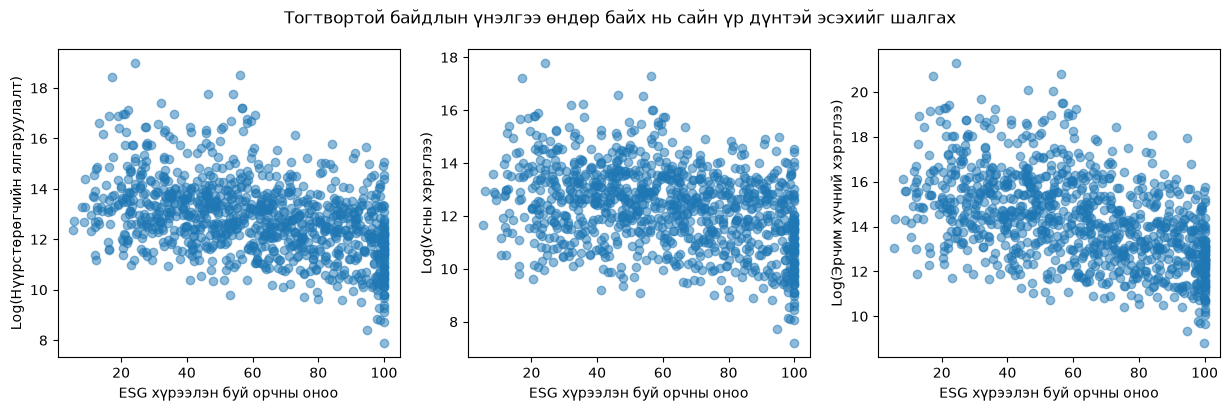

In [3]:
_esg = [
    'esg_environmental_score', 'carbon_emissions', 
    'water_usage', 'energy_consumption',
]

_df = df.loc[df['year'] == df['year'].max(), _esg].copy()

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].scatter(_df['esg_environmental_score'], np.log1p(_df['carbon_emissions']), alpha=0.5)
ax[1].scatter(_df['esg_environmental_score'], np.log1p(_df['water_usage']), alpha=0.5)
ax[2].scatter(_df['esg_environmental_score'], np.log1p(_df['energy_consumption']), alpha=0.5)

ax[0].set_xlabel('ESG хүрээлэн буй орчны оноо')
ax[0].set_ylabel('Log(Нүүрстөрөгчийн ялгаруулалт)')

ax[1].set_xlabel('ESG хүрээлэн буй орчны оноо')
ax[1].set_ylabel('Log(Усны хэрэглээ)')

ax[2].set_xlabel('ESG хүрээлэн буй орчны оноо')
ax[2].set_ylabel('Log(Эрчим хүчний хэрэглээ)')

fig.suptitle('Тогтвортой байдлын үнэлгээ өндөр байх нь сайн үр дүнтэй эсэхийг шалгах')

del _df, ax

Дээрх график дээр үзүүлсний дагуу хүлэмжийн хийн ялгаруулалт, усны хэрэглээ, эрчим хүчний хэрэглээ багасах тутамд ESG оноо ихсэж байгаа нь бидний assumption-г дэмжиж байна. Ө.х. өндөр ESG = тогтвортой хөгжил засаглал. 

Харин одоо хугацааны цуваа бүхий компаний датаг cross-sectional дата болгож хувиргах хэрэгтэй. Тухайн компани өнгөрсөнд ямар байсан нь хамаагүй, хамгийн сүүлийн үеийн үнэлгээгээр тогтвортой гэж үнэлэгдсэн эсэх нь л компаний категорийг тодорхойлоход шаардлагатай учир эхлээд хамгийн сүүлийн жилүүдийг харгалзаж үзэхээр шийдлээ.

In [4]:
# Кросс-секшн агшин: зөвхөн хамгийн сүүлийн жил (present-state). Эрсдэл бол
# одоогийн төлөв тул шошгыг бүх цувааны дунджаар биш, сүүлийн жилийн оноогоор
# тодорхойлно (өнгөрсний "бохирдол"-оос сэргийлнэ).
LATEST = int(df.year.max())
snap = df[df.year == LATEST].copy()

# Бинар шошго: stakeholder зөвхөн ЭРСДЭЛТЭЙ компанид анхаардаг (аль хэдийн аюулгүй
# буюу дунд зэрэг нь бараг үнэ цэнгүй) тул "risky vs not_risky" болгов.
# Босго = 50: Refinitiv/LSEG-ийн 0-100 ESG оноо нь квартилиар D(0-25), C(25-50),
# B(50-75), A(75-100) зэрэглэгддэг; доод хоёр квартиль (C, D) нь below-average тул эрсдэлтэй.
RISK_THRESHOLD = 50
snap['risk'] = np.where(snap['esg_overall_score'] < RISK_THRESHOLD, 'risky', 'not_risky')

# Хазайлттай баганад лог; ашиг/өсөлт нь тэмдэгтэй тул хэвээр.
for c in ['revenue', 'market_cap', 'carbon_emissions', 'water_usage', 'energy_consumption']:
    snap['log_' + c] = np.log(snap[c])

FIN = ['log_revenue', 'log_market_cap', 'profit_margin', 'growth_rate']       # санхүүгийн фичер
FOOT = ['log_carbon_emissions', 'log_water_usage', 'log_energy_consumption']  # байгаль орчны ул мөр
# e, s, g оноо нь шошгыг шууд тодорхойлдог (leakage) тул хасагдсан.

print('Snapshot:', snap.shape[0], 'компани |', LATEST, 'он | босго =', RISK_THRESHOLD)
print(snap['risk'].value_counts().to_string())

Snapshot: 1000 компани | 2025 он | босго = 50
risk
not_risky    702
risky        298


In [5]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, roc_auc_score
from sklearn.dummy import DummyClassifier

y = snap['risk']
# Хоёр загвар ижил хуваалт дээр (stratify ангиллын тэнцвэрийг хадгална);
# ялгаа нь зөвхөн фичерийн багц тул харьцуулалт шударга.
idx_tr, idx_te = train_test_split(snap.index, test_size=0.25, stratify=y, random_state=1)
yte_risky = (y.loc[idx_te] == 'risky').astype(int)   # ROC-AUC-д risky = positive

# Тэнцвэргүй ангид accuracy төөрөгдүүлдэг тул санамсаргүй суурийг risky-ангийн F1-ээр харуулъя.
for s in ['most_frequent', 'stratified']:
    dum = DummyClassifier(strategy=s, random_state=1).fit(snap.loc[idx_tr, FIN], y.loc[idx_tr])
    base = f1_score(y.loc[idx_te], dum.predict(snap.loc[idx_te, FIN]), pos_label='risky', zero_division=0)
    print(f'Суурь ({s:13s}): risky F1 = {base:.3f}')

# Soft-margin RBF SVM. StandardScaler заавал (SVM масштабт мэдрэг), class_weight='balanced'
# нь цөөнх ангид унахаас сэргийлнэ. Сонголтын шалтгааныг доорх дүгнэлтээс үз.
def evaluate(features, name):
    clf = make_pipeline(StandardScaler(),
                        SVC(kernel='rbf', C=1.0, gamma='scale',
                            class_weight='balanced', random_state=1))
    clf.fit(snap.loc[idx_tr, features], y.loc[idx_tr])
    pred = clf.predict(snap.loc[idx_te, features])
    auc = roc_auc_score(yte_risky, clf.decision_function(snap.loc[idx_te, features]))
    print(f'\n=== {name} | {len(features)} фичер | ROC-AUC = {auc:.3f} ===')
    print(classification_report(y.loc[idx_te], pred, digits=3, zero_division=0))
    return clf

# Загвар 1: бүх leak-гүй атрибут (санхүү + байгаль орчны ул мөр).
m_full = evaluate(FIN + FOOT, 'M_full: санхүү + ул мөр')

Суурь (most_frequent): risky F1 = 0.000
Суурь (stratified   ): risky F1 = 0.267

=== M_full: санхүү + ул мөр | 7 фичер | ROC-AUC = 0.698 ===
              precision    recall  f1-score   support

   not_risky      0.824     0.560     0.667       175
       risky      0.412     0.720     0.524        75

    accuracy                          0.608       250
   macro avg      0.618     0.640     0.595       250
weighted avg      0.700     0.608     0.624       250



In [6]:
# Загвар 2: ул мөрийг хасч зөвхөн санхүү. Ул мөрийн хувь нэмрийг тусгаарлах ablation.
m_fin = evaluate(FIN, 'M_fin: зөвхөн санхүү')


=== M_fin: зөвхөн санхүү | 4 фичер | ROC-AUC = 0.546 ===
              precision    recall  f1-score   support

   not_risky      0.736     0.509     0.601       175
       risky      0.333     0.573     0.422        75

    accuracy                          0.528       250
   macro avg      0.534     0.541     0.511       250
weighted avg      0.615     0.528     0.547       250



## Дүгнэлт

**Юу хийсэн бэ.** `esg_overall_score`-ийн чиглэлийг (өндөр = тогтвортой) ул мөртэй урвуу хамаарлаар диаграмаар баталж, оноог present-state агшингаар (2025) босго 50-аар бинар шошго (`risky` vs `not_risky`) болгов; risky = доод хоёр квартиль (LSEG D/C). e, s, g оноог leakage гэж хасаж, санхүү болон байгаль орчны ул мөрөөр soft-margin SVM сургаад ablation (ул мөртэй vs зөвхөн санхүү) хийв.

**Үр дүн** (risky = positive, тест n = 250, risky F1-ийн stratified суурь = 0.27):

| Загвар | Фичер | ROC-AUC | risky recall | risky precision | risky F1 |
|---|---|---|---|---|---|
| M_fin | зөвхөн санхүү | 0.546 | 0.57 | 0.33 | 0.42 |
| M_full | санхүү + ул мөр | **0.698** | **0.72** | 0.41 | **0.52** |

- **M_full нь эрсдэлтэй компанийг бодитоор илрүүлнэ:** ROC-AUC 0.70, risky recall 0.72 (эрсдэлтэй компанийн ~72%-ийг барьж авна). Precision 0.41 нь хуурамч дохио бий гэсэн үг ч "эрсдэлтэйг бүү алдагдуул" гэсэн stakeholder-ийн зорилгод recall илүү чухал.
- **Санхүү дангаараа санамсаргүйтэй ойролцоо:** M_fin-ийн ROC-AUC = 0.546 (0.5 = random). risky F1 0.42 нь зөвхөн `class_weight`-ийн улмаас суурийг давсан мэт харагдах ч AUC нь санхүүгийн фичер эрсдэлийг бараг ялгахгүйг илчилнэ.
- **Бүх ялгах хүч ул мөрөөс ирнэ** (AUC 0.55-аас 0.70). Ул мөр нь байгаль орчны онооны прокси (carbon intensity vs env корреляц ~ -0.73), тиймээс шинэ нээлт биш, бараг механик холбоос.
- **Эцсийн дүгнэлт:** ESG эрсдлийг бинараар тодорхой хэмжээнд (AUC 0.70) илрүүлж болох ч энэ нь зөвхөн байгаль орчны ул мөрөөс ирдэг; санхүүгийн суурь үзүүлэлт бие даан мэдээлэл өгөхгүй.

**Яагаад SVM.** Ангиуд хоорондоо ихээр давхцсан тул зөөлөн зах (soft-margin) зайлшгүй; `C` нь алдааг зөвшөөрнө. Бага хэмжээ, бага хэмжээст дата (750 x 7) нь support vector-т суурилсан SVM-д тохиромжтой. RBF kernel нь ул мөрөөс эрсдэл рүү чиглэсэн шугаман бус хилийг барина. Тэнцвэргүй ангид `class_weight='balanced'`-гүй бол загвар not_risky мажоритод унаж risky recall-ыг алдана. Урьд RandomForest-оор ижил дүгнэлт гарсан тул загварын төрлөөс хамаарахгүй (robustness).

**Яагаад Deep Learning биш.** Хязгаарлагч хүчин зүйл нь мэдээлэл (signal), загварын багтаамж биш. Сигнал байхгүй газар гүн сүлжээ зөвхөн чимээ шуугианд overfit хийнэ. 750 мөр, 7 хэмжээст хавтгай tabular дата бол яг tree/SVM давамгайлдаг муж (Grinsztajn нар, 2022: tree-based загварууд tabular дээр DL-ийг тогтмол давдаг). DL-ийг оруулах цорын ганц шударга арга бол сөрөг хяналт (negative control), "DL хүртэл давж чадахгүй" гэдгийг харуулах. Тэр тохиолдолд ч жижиг tabular-д тусгайлан зориулсан TabPFN илүү тохиромжтой ч зөвхөн дээд хязгаарыг баталгаажуулна, нэмэлт сигнал гаргахгүй.